#### VAR Model

1.  VAR stands for Variable Autoregression.

2.  It influences itself as well as the other variables.

3.  Here we need to forecast all the variables together.

3.  It is atime series forecasting model that words with multiple time series variables.


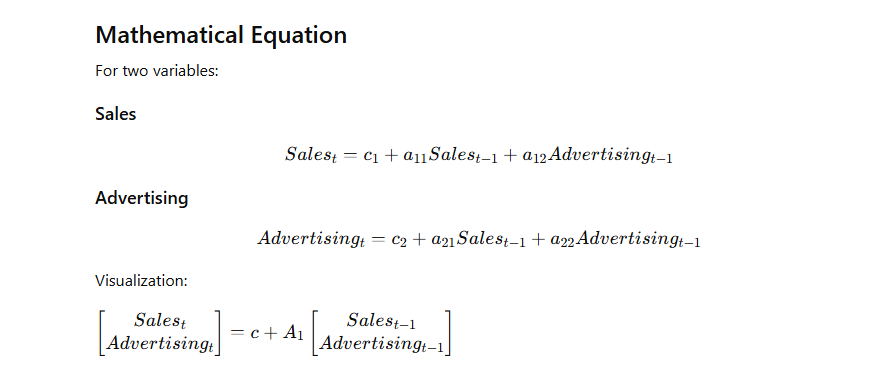


#### Step 1: Import all the necessary libraries

In [1651]:
import  numpy               as  np
import  pandas              as  pd
import  matplotlib.pyplot   as  plt
import  seaborn             as  sns

from    statsmodels.tsa.api         import  VAR
from    statsmodels.tsa.stattools   import adfuller

#### Step 2: Load the dataset

In [1652]:
df = pd.read_csv('economics.csv')

In [1653]:
df

,Date,Sales,Advertising
0,2020-01,100,20
1,2020-02,110,25
2,2020-03,120,30
3,2020-04,125,32
4,2020-05,130,35
5,2020-06,135,37
6,2020-07,145,40
7,2020-08,150,42
8,2020-09,155,45
9,2020-10,160,47


#### Step 3: Perform the Data Exploration

In [1654]:
#### get the first five rows of the dataset

df.head()

,Date,Sales,Advertising
0,2020-01,100,20
1,2020-02,110,25
2,2020-03,120,30
3,2020-04,125,32
4,2020-05,130,35


In [1655]:
#### get the last five rows of the dataset

df.tail()

,Date,Sales,Advertising
31,2022-08,375,115
32,2022-09,385,118
33,2022-10,395,120
34,2022-11,410,125
35,2022-12,425,130


In [1656]:
#### get the length of the dataset

print('Length of the dataset is:', len(df))

Length of the dataset is: 36


In [1657]:
#### get the shape of the dataset

print('Shape of the dataset is:', df.shape)

Shape of the dataset is: (36, 3)


In [1658]:
#### get the columns used in the dataset

df.columns

Index(['Date', 'Sales', 'Advertising'], dtype='object')

In [1659]:
#### get the information about the columns in the dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Date         36 non-null     object
 1   Sales        36 non-null     int64 
 2   Advertising  36 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 992.0+ bytes


In [1660]:
#### get the descriptive summary statistics for all the numeric columns in the dataset

df.describe()

,Sales,Advertising
count,36.000000,36.000000
mean,243.472222,73.611111
std,96.346246,31.687111
min,100.000000,20.000000
25%,158.750000,46.500000
50%,230.000000,71.500000
75%,322.500000,100.750000
max,425.000000,130.000000


In [1661]:
#### get the descriptive statistics for all the categorical columns in the dataset

df.describe(include='object')

,Date
count,36
unique,36
top,2020-01
freq,1


#### Step 4: Perform Data Cleaning and Feature Engineering

In [1662]:
#### convert the object type of date to the datetime type

df['Date'] = pd.to_datetime(df['Date'])

In [1663]:
#### again check for the information about the columns used in the dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Date         36 non-null     datetime64[ns]
 1   Sales        36 non-null     int64         
 2   Advertising  36 non-null     int64         
dtypes: datetime64[ns](1), int64(2)
memory usage: 992.0 bytes


In [1664]:
#### Make the Date column as the index

df.set_index('Date',inplace=True)

#### OBSERVATIONS:

1.  The Date column has been made an index in the dataframe.

In [1665]:
df

,Sales,Advertising
Date,,
2020-01-01,100,20
2020-02-01,110,25
2020-03-01,120,30
2020-04-01,125,32
2020-05-01,130,35
2020-06-01,135,37
2020-07-01,145,40
2020-08-01,150,42
2020-09-01,155,45


#### Step 5:  Visualize the data

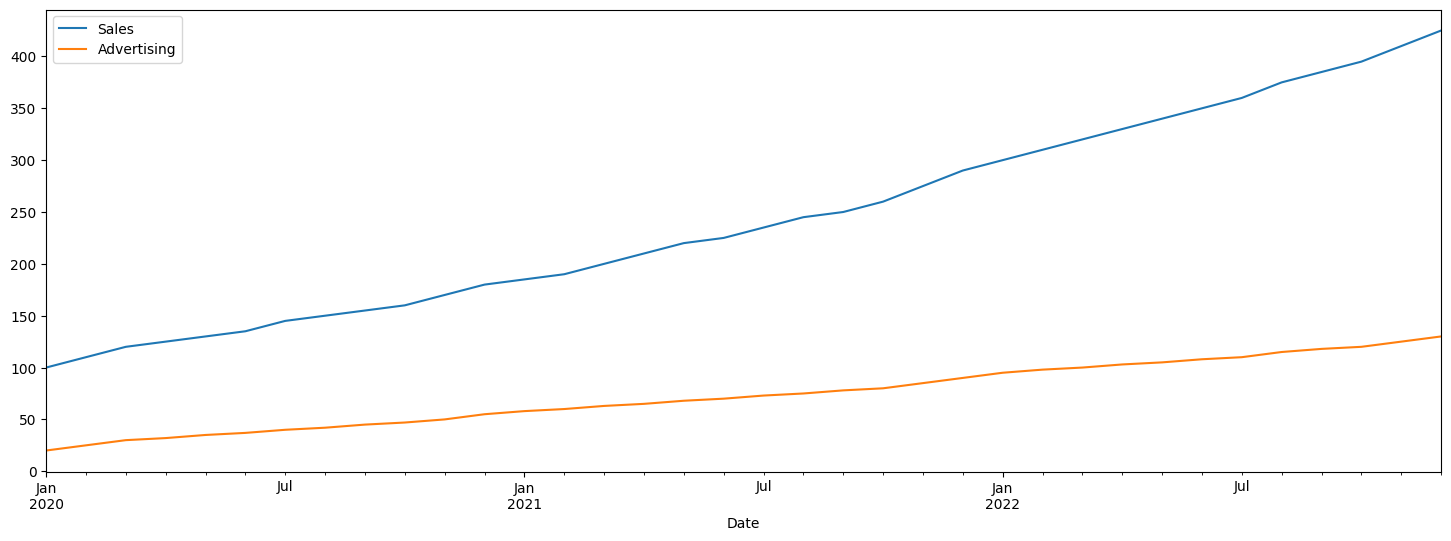

In [1666]:
#### Visualize the data

df.plot(figsize=(18,6))

plt.show()

#### OBSERVATIONS:

1.  Both Sales and Advertising follws an upward trend , so it is a non stationary time series data.

#### Step 6: Check the Stationarity of the time series data

In [1667]:
from statsmodels.tsa.stattools  import  adfuller

#### define the function
def adfullertest(series):
    #### perform adfuller function of the 'Sales' and 'Advertising' column of the dataset
    res = adfuller(series)

    #### print the details
    print('ADF Test Statistics is:', res[0])
    print('P Value is:', res[1])

In [1668]:
#### call the function
adfullertest(df['Sales'])

ADF Test Statistics is: 4.951460467408394
P Value is: 1.0


In [1669]:
adfullertest(df['Advertising'])

ADF Test Statistics is: 0.6194481944988784
P Value is: 0.988085311921991


#### OBSERVATIONS:

1.  If p-value < 0.05 ==============> then the series is stationary else non-stationary.

2.  In 'Sales' column , P-Value is 1 > 0.05 ============> So Sales is non-stationary.

3.  In 'Advertising' column, p-value is 0.9888 > 0.05 =============> So Advertising is non-stationary.

#### Step 7: Perform Differencing for the non stationary variables

In [1670]:
df

,Sales,Advertising
Date,,
2020-01-01,100,20
2020-02-01,110,25
2020-03-01,120,30
2020-04-01,125,32
2020-05-01,130,35
2020-06-01,135,37
2020-07-01,145,40
2020-08-01,150,42
2020-09-01,155,45


In [1671]:
#### After performing first order differencing on the 'Sales' and 'Advertising' columns of the dataset

df_diff = df.diff().dropna()

In [1672]:
df_diff

,Sales,Advertising
Date,,
2020-02-01,10.0,5.0
2020-03-01,10.0,5.0
2020-04-01,5.0,2.0
2020-05-01,5.0,3.0
2020-06-01,5.0,2.0
2020-07-01,10.0,3.0
2020-08-01,5.0,2.0
2020-09-01,5.0,3.0
2020-10-01,5.0,2.0


#### OBSERVATIONS:

1.  First Order Differencing has been performed on the non stationary time series objects of 'Sales' and 'Advertising' columns of the dataset.

#### Step 8: Train-Test Split

In [1673]:
#### divide the dataset into training and testing data
train = df_diff.iloc[:-12]
test  = df_diff.iloc[-12:]

In [1674]:
train

,Sales,Advertising
Date,,
2020-02-01,10.0,5.0
2020-03-01,10.0,5.0
2020-04-01,5.0,2.0
2020-05-01,5.0,3.0
2020-06-01,5.0,2.0
2020-07-01,10.0,3.0
2020-08-01,5.0,2.0
2020-09-01,5.0,3.0
2020-10-01,5.0,2.0


In [1675]:
train.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 23 entries, 2020-02-01 to 2021-12-01
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Sales        23 non-null     float64
 1   Advertising  23 non-null     float64
dtypes: float64(2)
memory usage: 552.0 bytes


In [1676]:
test

,Sales,Advertising
Date,,
2022-01-01,10.0,5.0
2022-02-01,10.0,3.0
2022-03-01,10.0,2.0
2022-04-01,10.0,3.0
2022-05-01,10.0,2.0
2022-06-01,10.0,3.0
2022-07-01,10.0,2.0
2022-08-01,15.0,5.0
2022-09-01,10.0,3.0


#### OBSERVATIONS:

1.  The main reason for dividing the dataset itno training and testing data is to check and estimate how well the model can perform on the future or the unseen data.

2.  Testing is for the last 12 records and the rest is for the training.

#### Step 9: Build VAR Model

In [1677]:
from statsmodels.tsa.api    import  VAR

#### Create an object for VAR
model = VAR(train)

c:\Users\DELL\Desktop\Complete_Data_Science\vens\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


#### OBSERVATIONS:

1.  The object for VAR Model has been created with the training data as the input.

2.  This is because with the help of the training data, the model will be trained.

3.  The model has been successfully made as we have already set the 'Date' column as the index.

#### Step 10: Select the Optimal lags

In [1678]:
#### VAR model with the past observations
selected_lags = model.select_order(maxlags=4)

In [1679]:
selected_lags

In [1680]:
#### get the summary of the lags

selected_lags.summary()

,AIC,BIC,FPE,HQIC
0,2.044*,2.144*,7.726*,2.061*
1,2.166,2.464,8.769,2.216
2,2.457,2.954,11.97,2.541
3,2.731,3.427,16.50,2.849
4,2.821,3.716,19.81,2.973


#### OBSERVATIONS:

1.  Here we have considered the VAR Model with past three observations.

2.  From all the observations, we can see that the VAR model with the current observations is having the least AIC score.

3.  So this observation provides the best lag and this is considred for the training purpose.

In [1681]:
#### get the best lag

best_lag = 1# selected_lags.aic

In [1682]:
best_lag

1

#### OBSERVATIONS:

1.  This provides the lag of the VAR model with the minimum aic score.

#### Step 11: Fit the VAR Model

In [1683]:
#### Train the model with the best lag

model_fit=model.fit(best_lag)

In [1684]:
model_fit

#### Step 12: Get the summary of the model

In [1685]:
model_fit.summary()

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sun, 31, May, 2026
Time:                     12:35:19
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                    2.49710
Nobs:                     22.0000    HQIC:                   2.26964
Log likelihood:          -80.6283    FPE:                    9.05181
AIC:                      2.19955    Det(Omega_mle):         7.00972
--------------------------------------------------------------------
Results for equation Sales
                    coefficient       std. error           t-stat            prob
---------------------------------------------------------------------------------
const                  6.436364         2.197765            2.929           0.003
L1.Sales               0.566545         0.280305            2.021           0.043
L1.Advertising        -0.934545         0.758975        

#### OBSERVATIONS:

1.  The VAR model estimates all the possible coefficients and gives the summary of the model.

#### Step 13: Forecast Future Values

In [1696]:
train.values

array([[10.,  5.],
       [10.,  5.],
       [ 5.,  2.],
       [ 5.,  3.],
       [ 5.,  2.],
       [10.,  3.],
       [ 5.,  2.],
       [ 5.,  3.],
       [ 5.,  2.],
       [10.,  3.],
       [10.,  5.],
       [ 5.,  3.],
       [ 5.,  2.],
       [10.,  3.],
       [10.,  2.],
       [10.,  3.],
       [ 5.,  2.],
       [10.,  3.],
       [10.,  2.],
       [ 5.,  3.],
       [10.,  2.],
       [15.,  5.],
       [15.,  5.]])

In [1686]:
#### Generate the forecast input
forecast_input = train.values[-best_lag:]

In [1687]:
forecast_input

array([[15.,  5.]])

In [1688]:
#### Generate the forecasting for the next 12 months

forecast = model_fit.forecast(
    y     = forecast_input                  ,
    steps = 12
)

In [1689]:
forecast

array([[10.26181818,  3.968     ],
       [ 8.54187372,  3.24932655],
       [ 8.23908001,  3.02560901],
       [ 8.27660782,  2.99672105],
       [ 8.32486614,  3.00641582],
       [ 8.34314647,  3.01382364],
       [ 8.34658016,  3.01622631],
       [ 8.3462801 ,  3.0165684 ],
       [ 8.3457904 ,  3.01647889],
       [ 8.34559662,  3.01640276],
       [ 8.34555798,  3.01637703],
       [ 8.34556013,  3.01637304]])

In [1690]:
####  Convert Forecast to DataFrame

forecast_df = pd.DataFrame(
    forecast                                ,
    index     =     test.index              ,
    columns   =     test.columns
)

In [1691]:
forecast_df

,Sales,Advertising
Date,,
2022-01-01,10.261818,3.968000
2022-02-01,8.541874,3.249327
2022-03-01,8.239080,3.025609
2022-04-01,8.276608,2.996721
2022-05-01,8.324866,3.006416
2022-06-01,8.343146,3.013824
2022-07-01,8.346580,3.016226
2022-08-01,8.346280,3.016568
2022-09-01,8.345790,3.016479


#### OBSERVATIONS:

1.  VAR model uses the past observations to predict the future values.

2.  Then we have performed the forecasting for the next 12 months.

#### Step 14: Evaluate Model

In [1692]:
from sklearn.metrics import root_mean_squared_error

rmse_sales = root_mean_squared_error(test['Sales'], forecast_df['Sales'])

print(rmse_sales)

3.592344313141337


In [1693]:
rmse_advertising = root_mean_squared_error(test['Advertising'], forecast_df['Advertising'])

print(rmse_advertising)

1.192397275300542


#### OBSEERVATIONS:

1.  Lower the RMSE ==================>  better is the model.

#### Step 15: Plot the Actual vs Forecasted Values

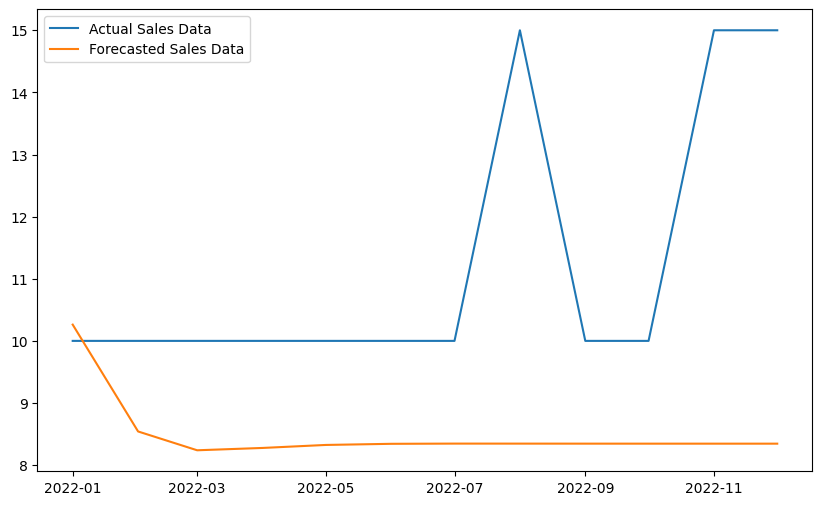

In [1694]:
plt.figure(figsize=(10,6))

#### plot the original data points
plt.plot(test.index, test['Sales'], label = 'Actual Sales Data')

#### plot the forecasted data points
plt.plot(forecast_df.index, forecast_df['Sales'], label = 'Forecasted Sales Data')

plt.legend()

#### display the graph
plt.show()

#### OBSERVATIONS:

1.  The above graph represents that the actual sales data is much higher than the forecasted sales data.